## Setup and Data Loading

In [3]:
pip install pandas matplotlib seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.


## Data Cleaning

In [4]:
import pandas as pd

df = pd.read_csv('../data/student_exam_performance_dataset.csv')
print(df.shape)
print(df.head())

(10000, 23)
  student_id  gender  age parental_education family_income internet_access  \
0     S00001    Male   17        High School        Medium             Yes   
1     S00002  Female   18        High School           Low             Yes   
2     S00003    Male   17        High School        Medium              No   
3     S00004    Male   18           Bachelor        Medium             Yes   
4     S00005    Male   18           Bachelor        Medium             Yes   

  study_environment  study_hours_per_day  attendance_rate  sleep_hours  ...  \
0             Quiet                 2.98             96.5         6.05  ...   
1             Quiet                 4.45             95.7         6.96  ...   
2             Quiet                 3.75             76.0         7.02  ...   
3             Quiet                 2.03             72.6         6.23  ...   
4             Quiet                 5.14             87.3         8.54  ...   

   online_courses_completed  tutoring  math_

In [5]:
print(df.isnull().sum())
print(df.dtypes)

student_id                    0
gender                        0
age                           0
parental_education            0
family_income                 0
internet_access               0
study_environment             0
study_hours_per_day           0
attendance_rate               0
sleep_hours                   0
social_media_hours            0
assignment_completion_rate    0
participation_score           0
online_courses_completed      0
tutoring                      0
math_score                    0
reading_score                 0
writing_score                 0
science_score                 0
final_exam_score              0
previous_gpa                  0
pass_fail                     0
grade_category                0
dtype: int64
student_id                     object
gender                         object
age                             int64
parental_education             object
family_income                  object
internet_access                object
study_environment      

In [6]:
print(df.duplicated().sum())

0


# What Really Determines Student Exam Performance?
### A Data-Driven Analysis of 10,000 Students

There are many predictors which can be used to determine future academic success, most stemming from either a student's background or the amount of effort they put in, such as family income or the amount of hours studied. I aim to see which of these groups contributes the most to a student's exam scores. 

In this blog, I will analyse a dataset of 10,000 students to see what really drives exam performance.
.

## The Dataset

The data used in this blog is from Kaggle, titled "Student Exam Performance Dataset". It contains information from 10,000 students on 23 variables, covering 3 categories. The first category is background factors, containing variables such as: parental education, family income and gender. The second category is effort and habits, containing variables like: study hours per day, sleep hours and attendance rate. The final category is academic outcome, including variables: maths, reading and writing scores and final exam scores. 

The table below summarises a few key numerical statistics which will be used in the analysis.

In [7]:
df[['study_hours_per_day', 'attendance_rate', 'sleep_hours', 
    'social_media_hours', 'final_exam_score', 'previous_gpa']].describe().round(2)

,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,final_exam_score,previous_gpa
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,3.02,84.70,7.02,2.52,49.68,1.98
std,1.18,9.51,0.99,1.45,12.15,0.54
min,0.50,50.80,4.00,0.00,4.40,0.00
25%,2.20,78.28,6.34,1.50,41.60,1.61
50%,3.01,85.10,7.03,2.50,49.55,1.99
75%,3.83,91.90,7.69,3.50,57.60,2.35
max,7.24,100.00,10.00,8.00,97.80,3.99


## How did students perform overall?

Before exploring what predicts exam scores it would be useful to understand how students performed. The histogram below will visualise the distribution of results from the 10,000 students.

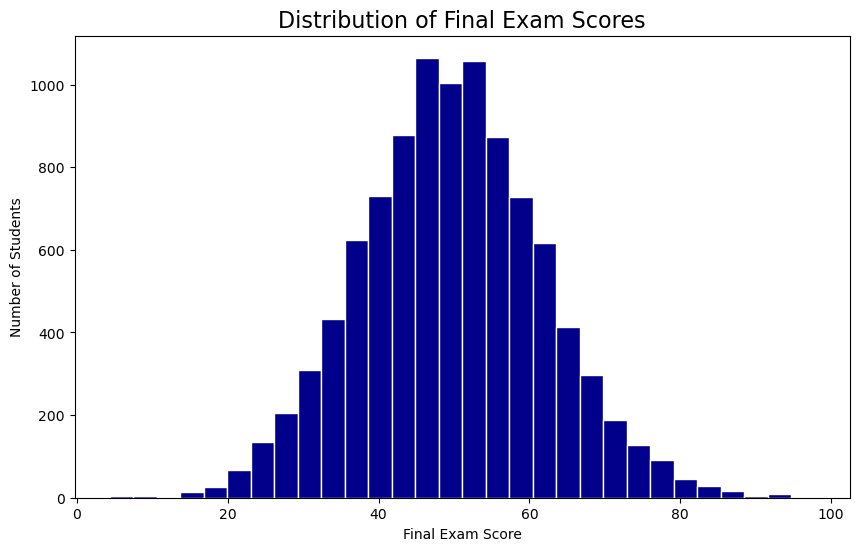

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['final_exam_score'], bins=30, color='darkblue', edgecolor='white')
plt.title('Distribution of Final Exam Scores', fontsize=16)
plt.xlabel('Final Exam Score')
plt.ylabel('Number of Students')
plt.show()

This graph shows that scores are roughly normally distributed, with most scoring between 40-60 and few students are achieving in the extremes, 80+ and 0-20. 

## Does family background matter?

Now lets look into how family background affects final exam scores by comparing related variables with the final exam results. First we will look at family income.

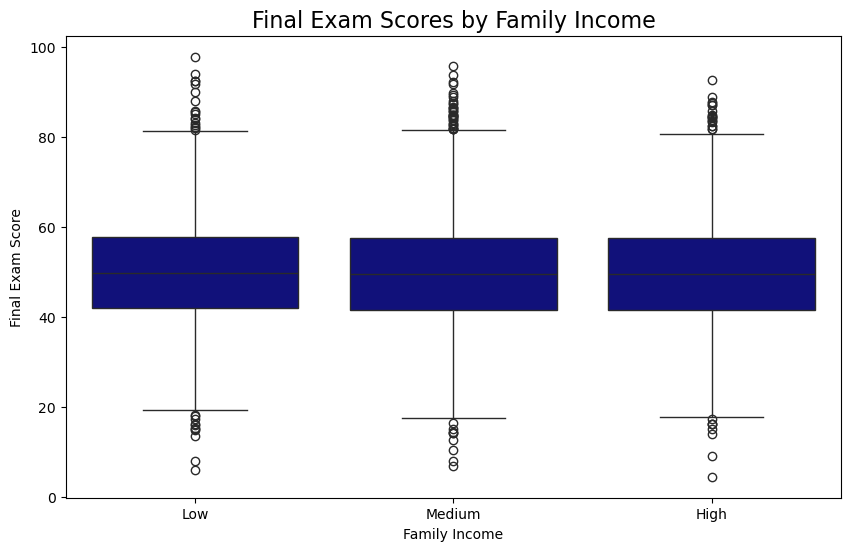

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='family_income', y='final_exam_score', 
            order=['Low', 'Medium', 'High'], color='darkblue')
plt.title('Final Exam Scores by Family Income', fontsize=16)
plt.xlabel('Family Income')
plt.ylabel('Final Exam Score')
plt.show()

This graph shows that there really is not much difference in median exam scores, with all around the 50 mark. There is also a similar spread of results with the interquartile range being similar across all of the different groups.This suggests that family income has little to no effect on final exam scores. 

Next we will look at if parental education has any effect on exam results.

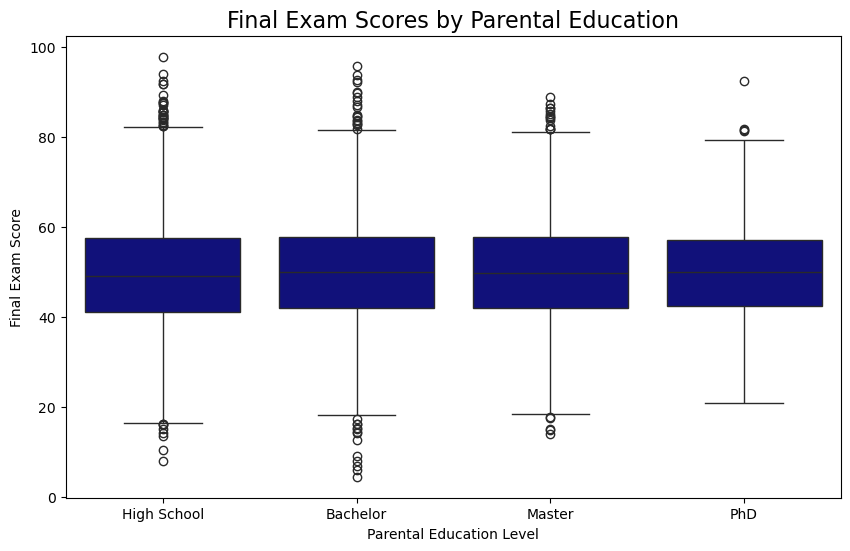

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='parental_education', y='final_exam_score',
            order=['High School', 'Bachelor', 'Master', 'PhD'],
            color='darkblue')
plt.title('Final Exam Scores by Parental Education', fontsize=16)
plt.xlabel('Parental Education Level')
plt.ylabel('Final Exam Score')
plt.show()

The above graph also shows little to no difference in median scores, again all around the 50 mark. This shows that parental education level has a negligible effect on students' final exam scores. 

Both of the previous two graphs suggest that background has almost no effect on a student's results. So, now we will look at how much effort these students are putting into improving their grades and seeing if this has a greater effect. 

## Does effort matter?

After looking at 2 key indicators to a student's background and how that can affect their exam results we will now work on whether or not their effort has any effect on their final exam results. First, we will look at how study hours per day has an effect on final exam score and then we will look at attendance rate.

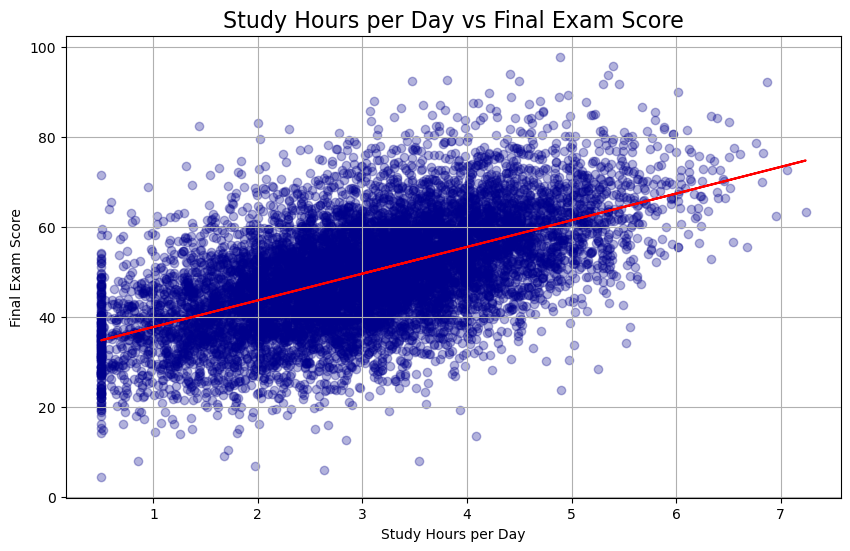

In [11]:
import numpy as np

x_values = df['study_hours_per_day']
y_values = df['final_exam_score']

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.3, color='darkblue')
m, b = np.polyfit(x_values, y_values, 1)
plt.plot(x_values, m * x_values + b, color='red')
plt.title('Study Hours per Day vs Final Exam Score', fontsize=16)
plt.xlabel('Study Hours per Day')
plt.ylabel('Final Exam Score')
plt.grid(True)
plt.show()

Here you can clearly see a positive correlation between study hours per day and final exam score, implying that the more a student is studying the greater their final exam result will be.

Now, we will visualise attendance rate against final exam results to see if this form of effort also has a positive correlation. 

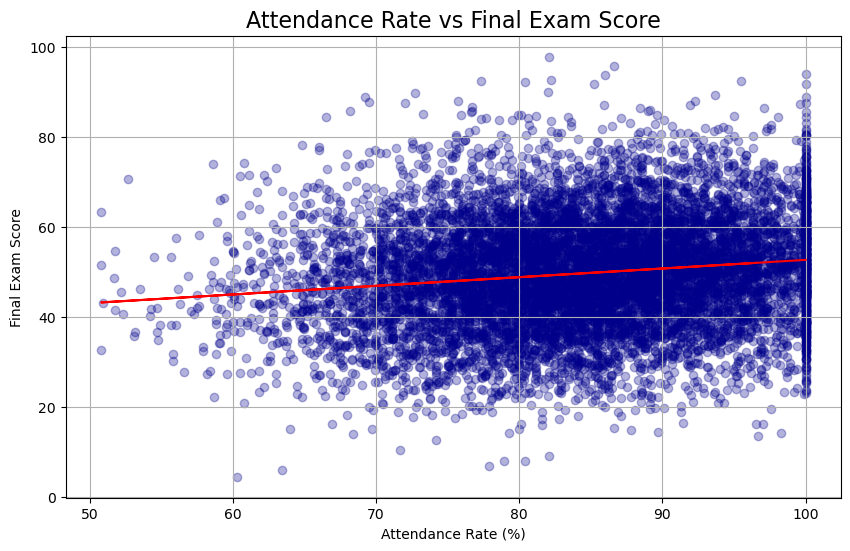

In [12]:
x_values = df['attendance_rate']
y_values = df['final_exam_score']

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.3, color='darkblue')
m, b = np.polyfit(x_values, y_values, 1)
plt.plot(x_values, m * x_values + b, color='red')
plt.title('Attendance Rate vs Final Exam Score', fontsize=16)
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Final Exam Score')
plt.grid(True)
plt.show()

Here there is also a weak positive correlation, but still positive, between attendance rate and final exam score, suggesting that as attendance rate increases as will final exam score. It also cuts off at 50% attendance rate as no student had below that percentage. 

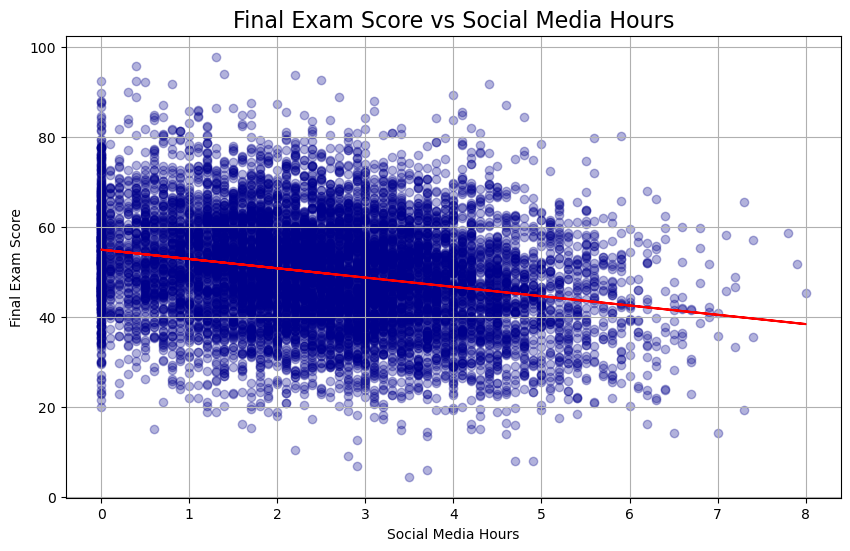

In [16]:
x_values = df['social_media_hours']
y_values = df['final_exam_score']

plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.3, color='darkblue')
m, b = np.polyfit(x_values, y_values, 1)
plt.plot(x_values, m * x_values + b, color='red')
plt.title('Final Exam Score vs Social Media Hours', fontsize=16)
plt.xlabel('Social Media Hours')
plt.ylabel('Final Exam Score')
plt.grid(True)
plt.show()

## Regression Analysis

We have now visualised our data and it has begin to paint a picture that effort matters more than a student's background as to their final exam score. However, now we will use regression analysis to further confirm my findings as well as find out which individual factors are the strongest cause of higher exam results. 

In [14]:
import statsmodels.api as sm

# Convert family_income to numbers
df['family_income_coded'] = df['family_income'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Convert parental_education to numbers
df['parental_education_coded'] = df['parental_education'].map(
    {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})

# Check it worked
print(df[['family_income', 'family_income_coded', 
          'parental_education', 'parental_education_coded']].head())

  family_income  family_income_coded parental_education  \
0        Medium                    1        High School   
1           Low                    0        High School   
2        Medium                    1        High School   
3        Medium                    1           Bachelor   
4        Medium                    1           Bachelor   

   parental_education_coded  
0                         0  
1                         0  
2                         0  
3                         1  
4                         1  


In [15]:
# Define our variables
X = df[['study_hours_per_day', 'attendance_rate', 'sleep_hours', 
        'social_media_hours', 'family_income_coded', 'parental_education_coded']]
y = df['final_exam_score']

# Add a constant
X = sm.add_constant(X)

# Run the regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       final_exam_score   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     1201.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:59:27   Log-Likelihood:                -36447.
No. Observations:               10000   AIC:                         7.291e+04
Df Residuals:                    9993   BIC:                         7.296e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

This provides us many key findings, the first of which being an R-squared value of 0.419, meaning that 41.9% of variation in  final exam score is determined by these 6 variables. This means that these variables are very important in determining how well a student will perform, however some variables have a much greater effect than others. Family income and parental education both have coefficients less than 0.1 meaning for each level they go up, either a higher level of income or a higher level of education, their final exam score goes up by less than 0.1. Unlike these variables, study hours per day has a coefficient of 5.95, meaning that for each extra hour their final result will increase by 6, which is very important to their overall score. Also, family income and parental education have p-values of 0.513 and 0.361, respectively, meaning that they are not statistically significant at 5% significance level, whereas the other 4 variables are all below this threshold meaning that they are statistically significant. 

## Conclusion

After conducting my my analysis into the question 'What really determines student exam performance?' there is a clear answer being presented by my findings. Despite people often crediting family background, either education or income, the data shows that it had no statistically significant impact on exam results, with students from low income families performing just as well as those from high income families or even having parents with a PhD having almost no difference to those with parents with just a High School education. 

What really made the difference was the amount of effort the student themselves made, with study hours per day being the best predictor of a student's exam performance, with 1 extra hour of study being rewarded with nearly 6 more marks on the final exam. Other notable predictors were sleep and social media usage, with social media having a negative impact on exam results whilst sleep was positive. 

The results are clear, it does not matter what sort of background a student has, it matters how much you work towards your exams. So, instead of giving up because you think other student's have it naturally easier, you should study more, sleep more and put the phone down. 